In [2]:
import torch
from PIL import Image
from IPython import display

import pandas as pd
import torchvision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', weights='MobileNet_V2_Weights.DEFAULT', verbose=False)
model.eval()

# put the model on a GPU if available, otherwise CPU
model.to(device);

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 97.6MB/s]


In [7]:


# Define the transforms for preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),  # Resize the image to 256x256
    transforms.CenterCrop(224),  # Crop the image to 224x224 about the center
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Normalize the image with the ImageNet dataset mean values
        std=[0.229, 0.224, 0.225]  # Normalize the image with the ImageNet dataset standard deviation values
    )
]);

In [8]:
unnormalize = transforms.Normalize(
   mean= [-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
   std= [1/s for s in [0.229, 0.224, 0.225]]
)

In [4]:
def tensor_to_pil(img_tensor):
    # tensor: pre-processed tensor object resulting from preprocess(img).unsqueeze(0)
    unnormed_tensor = unnormalize(img_tensor)
    return transforms.functional.to_pil_image(unnormed_tensor[0])

Finally, we load the labels that match output index to the class of the output.

In [10]:
# load labels
with open("/content/labels.txt", 'r') as f:
    labels = [label.strip() for label in f.readlines()]

Models require numbers in and give numbers back. You use these labels (one per line) to recover the human-readable output. If you get them wrong, you _will_ introduce bugs in downstream systems. We hesitate to say it's a bug of the model, as the model does numbers in, numbers out, but it can be a big deal if implemented incorrectly.

Next, we'll load an image we got off the Internet and run it through the `preprocess` pipeline.

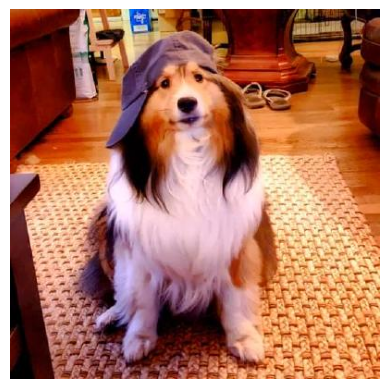

In [5]:
# DO NOT CHANGE

# load an example image
img = Image.open("/content/Riley.jpg")

plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
# preprocess the image - Add Batch Dimension
img_tensor = preprocess(img).unsqueeze(0)

print(f"Inputs information:\n---------------\nshape:{img_tensor.shape}\n")

Inputs information:
---------------
shape:torch.Size([1, 3, 224, 224])



In [12]:
# move sample to the right device
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)

In [13]:
print(f"Image tensor on device:\n---------------\n{img_tensor.device}\n")
print(f"Inputs information:\n---------------\nshape:{img_tensor.shape}\nclass: {type(img_tensor)}\n")
print(f"Shape of outputs:\n---------------\n{output.shape}\n")
print(f"Pred Index:\n---------------\n{output[0].argmax()}\n")
print(f"Pred Label:\n---------------\n{labels[output[0].argmax()]}\n")

Image tensor on device:
---------------
cuda:0

Inputs information:
---------------
shape:torch.Size([1, 3, 224, 224])
class: <class 'torch.Tensor'>

Shape of outputs:
---------------
torch.Size([1, 1000])

Pred Index:
---------------
230

Pred Label:
---------------
Shetland sheepdog



We can take the preprocessed image and convert it back to a standard image format. Note that it's been cropped, and the resizing operation has left it slightly smaller.

In [14]:
img_pil = tensor_to_pil(img_tensor)
img_pil.show()

"Evasion" With Random Noise

In [40]:
queries = 1000
target_output = 235
output_index = 1000
i = 0

max_val = torch.max(img_tensor)
min_val = torch.min(img_tensor)
modifier = max_val-min_val
while not output_index == target_output:
    tensor = torch.randn(3, 224, 224).to(device) * modifier + min_val
    tensor = tensor.unsqueeze(0).to(device)
    output = model(tensor)
    output_index = output[0].argmax()
    output_label = labels[output_index]
    i+=1
    if i%100==1:
        print(output_index,output_label)
    if i == queries:
        break
print(output_index,output_label)# print every 100th

tensor(599, device='cuda:0') honeycomb
tensor(599, device='cuda:0') honeycomb
tensor(490, device='cuda:0') chain mail
tensor(955, device='cuda:0') jackfruit
tensor(955, device='cuda:0') jackfruit
tensor(599, device='cuda:0') honeycomb
tensor(599, device='cuda:0') honeycomb
tensor(490, device='cuda:0') chain mail
tensor(599, device='cuda:0') honeycomb
tensor(490, device='cuda:0') chain mail
tensor(599, device='cuda:0') honeycomb


In [16]:

# define how much we want to change the image
change = 1e-3

# create new img_tensor
img_tensor = preprocess(img).unsqueeze(0)

# create the halloween mask
mask = torch.randn_like(img_tensor)*change

# turn in into something torch can work with
mask_parameter = torch.nn.Parameter(mask)

# create the final dog + noise
masked_img_tensor = img_tensor + mask_parameter

print(f"Mask shape:\n---------------\n{mask.shape}\n")

Mask shape:
---------------
torch.Size([1, 3, 224, 224])



When we look at the samples side-by-side, despite looking the same and being predicted as the same, they are ever so slightly different.

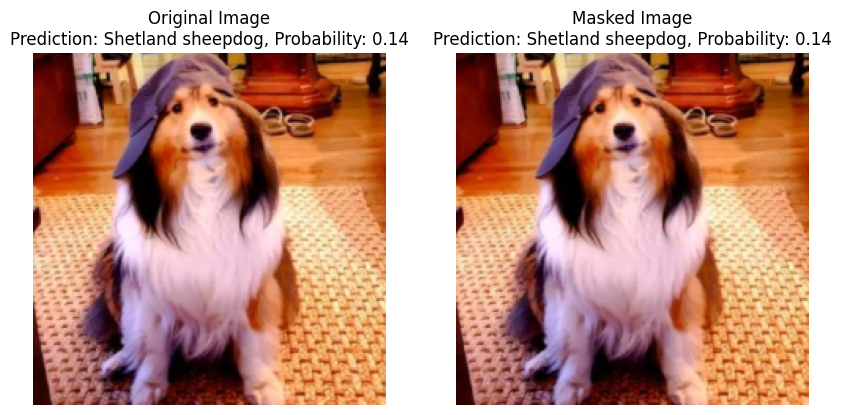

In [17]:
img_tensor = img_tensor.to(device)
masked_img_tensor = masked_img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)
    masked = model(masked_img_tensor)

    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    mask_probs = torch.softmax(masked, dim=1)[0][masked[0].argmax()].item()

    prediction = labels[output[0].argmax()]
    mask_prediction = labels[masked[0].argmax()]

    img_pil = tensor_to_pil(img_tensor)
    masked_pil = tensor_to_pil(masked_img_tensor)

plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction}, Probability: {probs:.2f}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked_pil)
plt.title(f"Masked Image\nPrediction: {mask_prediction}, Probability: {mask_probs:.2f}")
plt.axis('off')

plt.show()

Here we show you the distance between the two images.

In [30]:
l2_norm = torch.norm(img_tensor - masked_img_tensor, p=2)
print("Distance (L2 norm) between original image and masked image:\n---------------\n", l2_norm.item())

Distance (L2 norm) between original image and masked image:
---------------
 1.0922553539276123


In [19]:
# DO NOT CHANGE

# parameters let the optimizer know how to update them (rather than just tensors, which you have to manage by hand)
mask_parameter = torch.nn.Parameter(mask.to(device))

# set the target to our mask, not the model
optimizer = torch.optim.Adam([mask_parameter])

# Find our current prediction
current_index = model(img_tensor)[0].argmax().unsqueeze(0)

Remember from the `torch` lab that  `.to(device)` creates a new node on a compute graph, if we kept the original `mask_parameter.to_device(device)`, we'd get a new tensor on the GPU instead of creating a leaf in the compute graph.

#### Customized Loss Function


In [21]:
def loss_function(output, mask, current_index):
    # - loss function is actually a "gain" function, incrementing towards a new label
    classification_loss = -torch.nn.functional.cross_entropy(output, current_index)

    # - Keep the numbers low so as not to be detected.
    l2_loss = torch.pow(mask, 2).sum()

    total_loss = classification_loss+l2_loss

    return total_loss, classification_loss, l2_loss

#Optimize the input (adversarial mask) perturbation instead of the weight

In [27]:
current_index = model(img_tensor)[0].argmax().unsqueeze(0)

while True:

    output = model(img_tensor+mask_parameter)
    total_loss, class_loss, l2_loss = loss_function(output, mask_parameter, current_index)
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    print("Total loss: {:4.4f}    class loss:{:4.4f}     l2 loss: {:4.4f}   Predicted class index:{}".format(
        total_loss.item(), class_loss.item(), l2_loss.item(), output[0].argmax()
    ))



    if output[0].argmax()!=current_index:
        break

print(f"Winner winner: {labels[output[0].argmax()]}")

Total loss: -3.1887    class loss:-4.3412     l2 loss: 1.1525   Predicted class index:160
Winner winner: Afghan hound


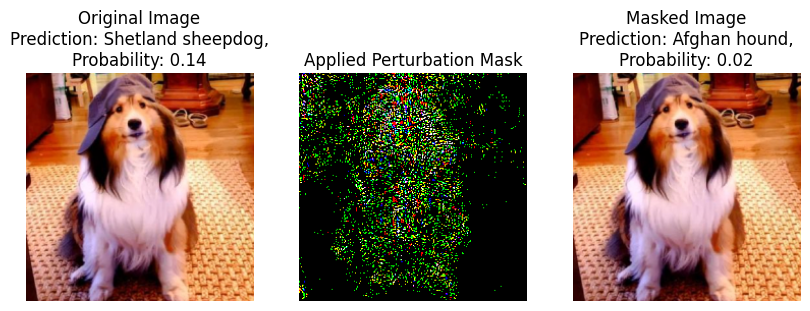

In [28]:
with torch.no_grad():
    output = model(img_tensor)
    masked = model(img_tensor+mask_parameter)

    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    mask_probs = torch.softmax(masked, dim=1)[0][masked[0].argmax()].item()

    prediction = labels[output[0].argmax()]
    mask_prediction = labels[masked[0].argmax()]

    unnormed_img_tensor= unnormalize(img_tensor)
    unnormed_mask_tensor= unnormalize(masked_img_tensor)

    img_pil = tensor_to_pil(img_tensor)
    masked_pil = tensor_to_pil(masked_img_tensor)

plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 3, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction},\nProbability: {probs:.2f}")
plt.axis('off')

mask_pil = transforms.functional.to_pil_image(mask_parameter[0])
plt.subplot(1, 3, 2)
plt.imshow(mask_pil)
plt.title(f"Applied Perturbation Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_pil)
plt.title(f"Masked Image\nPrediction: {mask_prediction},\nProbability: {mask_probs:.2f}")
plt.axis('off')

plt.show()

In [29]:
masked_img_tensor = img_tensor+mask_parameter

l2_norm = torch.norm(img_tensor - masked_img_tensor, p=2)
print("Distance (L2 norm) between original image and masked image:\n---------------\n", l2_norm.item())

Distance (L2 norm) between original image and masked image:
---------------
 1.0922553539276123


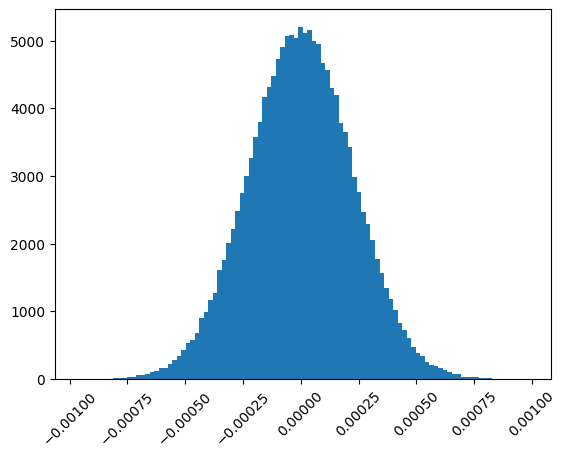

Minimum and maximum difference between the images: -0.0009663701057434082 0.0009843707084655762


In [31]:
difference = unnormed_mask_tensor - unnormed_img_tensor
difference_list = difference.view(-1).tolist()

# Plot the histogram
plt.hist(difference_list, bins=100)
plt.xticks(rotation=45)
plt.show()

print("Minimum and maximum difference between the images:", difference.min().item(), difference.max().item())

### Targeted_ Carlini and Wagner L2 Attack

In [32]:
# define how much we want to change the image
change = 1e-3

# create new img_tensor
img_tensor = preprocess(img).unsqueeze(0).to(device)

# create the halloween mask
mask = torch.randn_like(img_tensor)*change

# create the mask parameter
mask_parameter = torch.nn.Parameter(mask.to(device))

optimizer = torch.optim.Adam([mask_parameter])
target_index = model(img_tensor).argmax()

print(f"Pred Index:\n---------------\n{output[0].argmax()}\n")
print(f"Pred Label:\n---------------\n{labels[output[0].argmax()]}\n")

Pred Index:
---------------
230

Pred Label:
---------------
Shetland sheepdog



In [ ]:
# Pick a target

In [34]:
target_index = torch.tensor(labels.index('sea lion')).unsqueeze(0).to(device)
print("Target index is:\n---------------\n", target_index)

Target index is:
---------------
 tensor([150], device='cuda:0')


In [35]:
def loss(output, mask, target_index, l2_weight):
    # Now we're removing the negative, we want it to be classified as the target_index
    classification_loss = torch.nn.functional.cross_entropy(output, target_index)

    # this says "No single pixel should be big, and the total magnitude of all of them should be small"
    l2_loss = torch.pow(mask, 2).sum()

    total_loss =  classification_loss+(l2_weight * l2_loss)

    # Now we penalize large distortions a bit less.
    return total_loss, classification_loss, l2_loss

In [36]:
import sys

l2_weight = 0.5
step = 0

while True: # evaluate it until the prediction matches the target label
    output = model(img_tensor+mask_parameter)
    total_loss, class_loss, l2_loss = loss(output, mask_parameter, target_index, l2_weight)

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    step+=1

    sys.stdout.write(f"\rStep: {step}  total loss: {total_loss.item():4.4f}    class loss:{class_loss.item():4.4f}     l2 loss: {l2_loss.item():4.4f}   Predicted class index:{output[0].argmax()}");
    sys.stdout.flush()

    if output[0].argmax().item() == target_index.item():
        break

print(f"\n\nWinner winner: {labels[output[0].argmax()]}")

Step: 22  total loss: 4.3291    class loss:2.8025     l2 loss: 3.0532   Predicted class index:150

Winner winner: sea lion


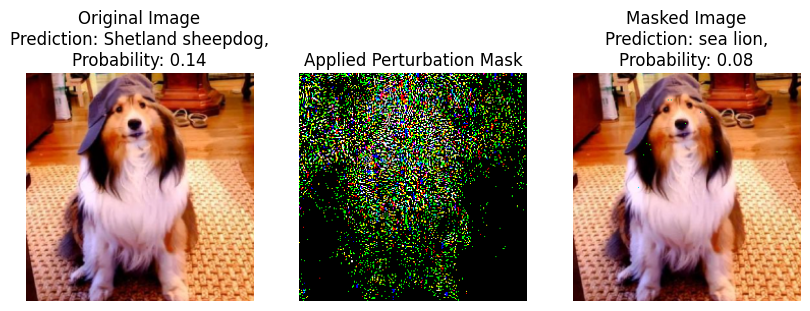

In [37]:
masked_img_tensor = img_tensor + mask_parameter

# get the model prediction and score for the original image and the masked image
with torch.no_grad():
    output = model(img_tensor)
    masked = model(masked_img_tensor)

    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    mask_probs = torch.softmax(masked, dim=1)[0][masked[0].argmax()].item()

    prediction = labels[output[0].argmax()]
    mask_prediction = labels[masked[0].argmax()]

    img_pil = tensor_to_pil(img_tensor)
    masked_pil = tensor_to_pil(masked_img_tensor)

plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 3, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction},\nProbability: {probs:.2f}")
plt.axis('off')

mask_pil = transforms.functional.to_pil_image(mask_parameter[0])
plt.subplot(1, 3, 2)
plt.imshow(mask_pil)
plt.title(f"Applied Perturbation Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_pil)
plt.title(f"Masked Image\nPrediction: {mask_prediction},\nProbability: {mask_probs:.2f}")
plt.axis('off')

plt.show()

In [38]:
l2_norm = torch.norm(img_tensor - masked_img_tensor, p=2)
print("Distance (L2 norm) between original image and masked image:\n---------------\n", l2_norm.item())

Distance (L2 norm) between original image and masked image:
---------------
 1.8025726079940796


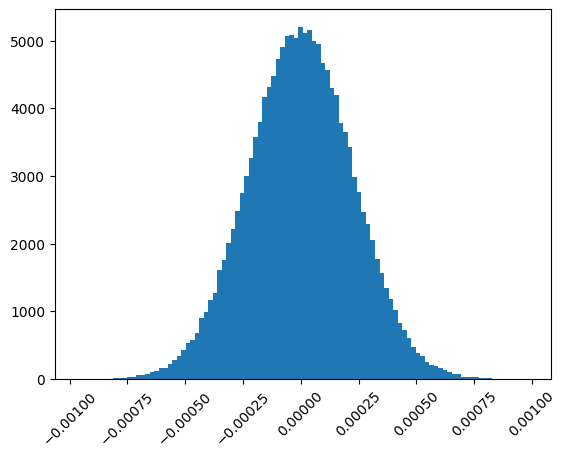

Minimum and maximum difference between the images: -0.0009663701057434082 0.0009843707084655762


In [39]:
difference = unnormed_mask_tensor - unnormed_img_tensor
difference_list = difference.view(-1).tolist()

# Plot the histogram
plt.hist(difference_list, bins=100)
plt.xticks(rotation=45)
plt.show()

print("Minimum and maximum difference between the images:", difference.min().item(), difference.max().item())